# Simulating Lightcurves

In [48]:
from popsycle import lightcurves, binary_utils, table_utils
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

First, run a PopSyCLE patch including multiples. This example is the one from [here](https://github.com/MovingUniverseLab/PopSyCLE/blob/main/docs/PopSyCLE_example_multiples.ipynb). This will give you a final set of tables. 

In [10]:
root = 'example_refined_events_ubv_I_Damineli16_'
events = Table.read(root + 'rb.fits')
companions = Table.read(root + 'companions_rb.fits')
multi_peaks = Table.read(root + 'companions_rb_multi_peaks.fits')
lightcurve_table = Table.read(root + 'rb_lightcurves.fits')

We then add a column to tell us the observable number of peaks which is used in the function to cut the table down. Then we make observational cuts on the minimum source ('S') or baseline ('LSN') magnitude, change in magnitude, and u0.

In [11]:
events = binary_utils.add_observable_peaks_column(events, 
                                             companions, 
                                             multi_peaks, 
                                             lightcurve_table, 
                                             delta_m_cutoff = 0.1, 
                                             delta_m_cutoff_secondary = 0.02,
                                             match_by_field = False)

In [42]:
events_cut, events_one_peak, events_multiples_cut_multi_peak = table_utils.cut_Mruns(events, 
                                                                          companions, 
                                                                          multi_peaks, 
                                                                          min_mag = 23, 
                                                                          delta_m_cut = 0.1, 
                                                                          u0_cut = 2,
                                                                          photometric_system='ubv',
                                                                          filter_name = 'I', 
                                                                          S_LSN = 'S')

We then generate a list of BAGLE models

In [44]:
model_list = lightcurves.get_bagle_model_list(events_cut, companions, lightcurve_table,
                                              filter_dict = {'ubv' :['I']}, red_law='Damineli16', n_multi_proc=3)

And simulate the lightcurves at times $t_0 \pm 2t_E$. The times in PopSyCLE are generated in arbitrary reference time such that if the survey generated is 1000 days long, the $t_0$ values will be between -500 and 500.

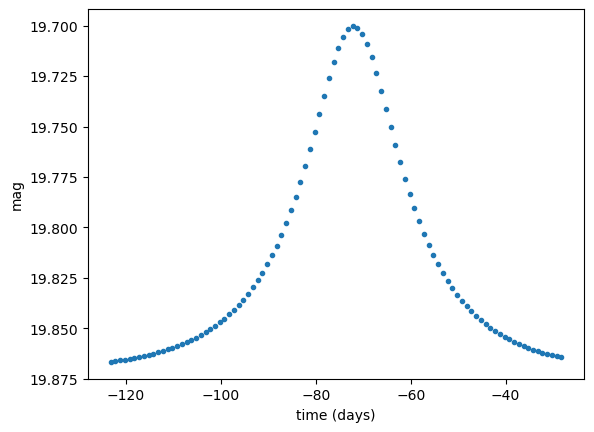

In [47]:
for model in model_list:
    times = np.arange(model.t0 - 2*model.tE, model.t0 + 2*model.tE)
    phot = model.get_photometry(times)
    plt.plot(times, phot, marker = '.', linestyle = 'None')
    plt.gca().invert_yaxis()
    plt.xlabel('time (days)')
    plt.ylabel('mag')
    plt.show()
    plt.close('all')